In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from sklearn import cluster
from joblib import Parallel, delayed
import rpy2

In [3]:
%load_ext rpy2.ipython

/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "XPC_SERVICE_NAME" redefined by R and overriding existing variable. Current: "application.com.jetbrains.pycharm.17019869.17020652", R: "0"
  warnings.warn(
/Users/judydw/Documents/UMich/Fall 2024/STATS 604/Project1/pythonProject/.venv/lib/python3.9/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T//Rtmpkmamvs", R: "/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T//Rtmp5mnZWy"
  warnings.warn(


In [6]:
%%R
options(repos = c(CRAN = "https://cloud.r-project.org"))  # Use RStudio’s mirror
install.packages("fastcluster") 
# install required pacakges


The downloaded binary packages are in
	/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T//RtmpxJHdyh/downloaded_packages


trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/fastcluster_1.3.0.tgz'
Content type 'application/x-gzip' length 258809 bytes (252 KB)
downloaded 252 KB



In [11]:
%%R
devtools::install_github("lucylgao/clusterpval") # install required packages


The downloaded binary packages are in
	/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T//RtmpxJHdyh/downloaded_packages
── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/private/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/RtmpxJHdyh/remotes13029580692e9/lucylgao-clusterpval-02fe37b/DESCRIPTION’ ... OK
* preparing ‘clusterpval’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘clusterpval_1.0.1.tar.gz’



* installing *source* package ‘clusterpval’ ...
** this is package ‘clusterpval’ version ‘1.0.1’
** using staged installation
** R
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (clusterpval)


Installing 6 packages: parallelly, listenv, globals, future, future.apply, intervals
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/parallelly_1.45.0.tgz'
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/listenv_0.9.1.tgz'
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/globals_0.18.0.tgz'
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/future_1.58.0.tgz'
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/future.apply_1.20.0.tgz'
trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/intervals_0.15.5.tgz'


In [4]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

n=30
p=2
mu = np.zeros(p)
sigma=1
#X = generate_null_data(n,p,mu,sigma)
X, y = make_blobs(n_samples=20, centers=4, cluster_std=0.1)
%R -i X

In [5]:
%%R
library(devtools)
library(fastcluster)
library(clusterpval)

Loading required package: usethis

Attaching package: ‘fastcluster’

The following object is masked from ‘package:stats’:

    hclust



[1] 3.576963e-07


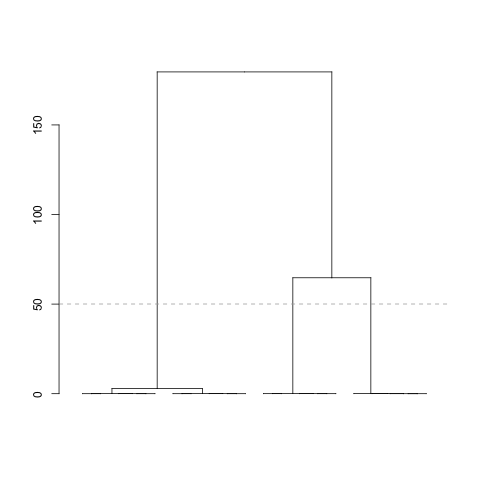

In [6]:
%%R
X = as.matrix(X)
hcl <- hclust(dist(X, method="euclidean")^2, method="average") 
plot(as.dendrogram(hcl), leaflab="none")
abline(h=(hcl$height[nrow(X) - 6] + 50), lty="dashed", col="darkgrey")
pval = test_complete_hier_clusters_approx(X, K=3, k1=2, k2=3, ndraws=10000, hcl=hcl)$pval
pval

In [7]:
%%R
X = as.matrix(X)
hcl <- hclust(dist(X, method="euclidean")^2, method="average") 
clust_labels <- cutree(hcl, k = 3)
tail(hcl$merge)

      [,1] [,2]
[14,]    8   11
[15,]   -7   12
[16,]    6   10
[17,]   13   16
[18,]   14   15
[19,]   17   18


In [92]:
%%R
get_cluster_obs <- function(hcl, node) {
  if (node < 0) {
    return(-node)
  } else {
    children <- hcl$merge[node, ]
    return(c(get_cluster_obs(hcl, children[1]),
             get_cluster_obs(hcl, children[2])))
  }
}
get_last_pair <- function(hcl,K){
   clust_labels <- cutree(hcl, k = K+1)
   #print(clust_labels)
   last_merge <- hcl$merge[nrow(hcl$merge) - K  + 1, ]
   cluster1 <- get_cluster_obs(hcl, last_merge[1])
   #print(cluster1)
   cluster2 <- get_cluster_obs(hcl, last_merge[2])
   #print(cluster2)
   label1 <- clust_labels[cluster1[1]]
   label2 <- clust_labels[cluster2[1]]
   #print((hcl$merge))
   return(c(label1,label2))
}

baseline_pval <- function(X,K, linkage, method = "euclidean"){
    hcl <- hclust(dist(X, method="euclidean")^2, method=linkage) 
    last_pair = get_last_pair(hcl,K)
    pval <- test_hier_clusters_exact(X, link=linkage, K=K+1, k1=last_pair[1], k2=last_pair[2], hcl=hcl)$pval
    
    #pair <- sample(1:K, 2)
    #k1 <- pair[1]
    #k2 <- pair[2]
    #pval <- test_hier_clusters_exact(X, link=linkage, K=2, k1=1, k2=2, hcl=hcl)$pval
    return(pval)
}
baseline_pval(X,3,"single")


[1] 0.2866655


In [93]:
#import numpy as np
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri

def get_baseline_pval(X, K, linkage="single"):
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage

    pval = ro.r("baseline_pval(X, K_py, link_py)")[0]
    return pval


In [94]:
def check_type1_baseline(n, p, sigma, K, alpha=0.05, num_trials=500):
    p_values = []
    mu = np.zeros(p)
    
    for _ in range(num_trials):
        X = generate_null_data(n, p, mu, sigma)
        p_val = get_baseline_pval(X, K, linkage="single")
        p_values.append(p_val)
    
    p_values = np.array(p_values)
    type_I_error = np.mean(p_values < alpha)
    
    return type_I_error

In [95]:
baseline_type1 = check_type1_baseline(n=30, p=2, sigma=1.0, K=3, alpha=0.05, num_trials=1000)

In [96]:
baseline_type1

np.float64(0.001)

In [97]:
def check_p_value_uniformity(n,p, sigma, K, num_trials=1000):
    p_values = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        p_value = get_baseline_pval(X, K, linkage="single")
        p_values.append(p_value)

    p_values = np.array(p_values)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

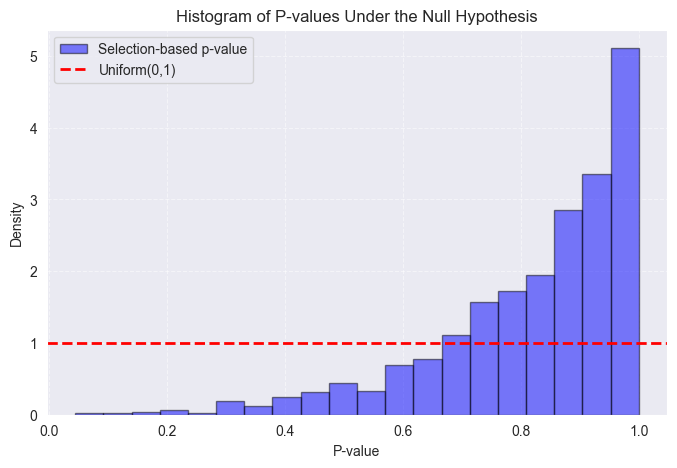

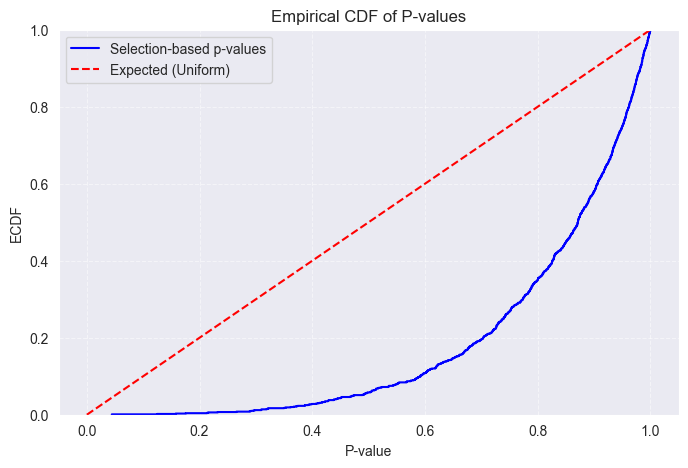

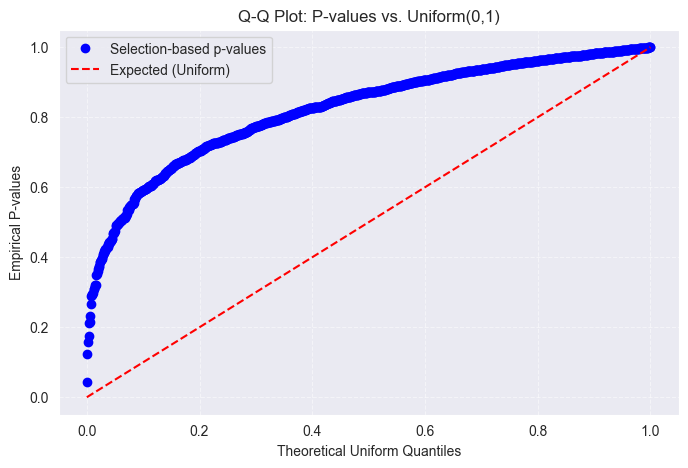

In [98]:
check_p_value_uniformity(30,2,1,5)

In [99]:
def check_type1_multi_tau(n, p, sigma, tau_list, K, layer, alpha=0.05, num_trials=500):
    type_I_error_rates = {}

    for tau in tau_list:
        p_values = []
        mu = np.zeros(p)
        for _ in range(num_trials):
            X = generate_null_data(n, p, mu, sigma)
            model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage="single")
            model.fit()

            winning_nodes = list(model.existing_clusters_log.keys())
            key = winning_nodes[layer]
            node = key[0].parent

            p_val, _, _ = model.merge_inference(node, grid_width=20, ncoarse=20, ngrid=1000, sd=sigma)
            p_values.append(p_val)

        type_I_error_rates[tau] = np.mean(np.array(p_values) < alpha)
    
    p_values = []
    for _ in range(num_trials):
        X= generate_null_data(n,p,mu,sigma)
        p_val = get_baseline_pval(X, K, linkage="single")
        p_values.append(p_val)
    
    p_values = np.array(p_values)
    type_I_error_rates["baseline"] = np.mean(p_values < alpha)

    # Plotting
    plt.figure(figsize=(8, 6))

    # Plot randomized points (tau > 0)
    taus_random = [tau for tau in tau_list if tau > 0]
    powers_random = [type_I_error_rates[tau] for tau in taus_random]
    plt.plot(taus_random, powers_random, marker='o', label="Randomized (τ > 0)", color='skyblue')

    # Plot naive point (tau = 0) separately
    if 0 in tau_list:
        plt.scatter(0, type_I_error_rates[0], color='orange', marker='s', s=100, label="Naive (τ = 0)", zorder=5)
    
    plt.scatter(-1,type_I_error_rates["baseline"],color="red", marker = 's', s=100, label="Gao et al.", zorder=5)
    # Horizontal line at significance level
    plt.axhline(y=alpha, linestyle='--', color='red', label=f"Significance level α = {alpha}")

    # Labels and title
    plt.xlabel("Tau (Randomization Level)")
    plt.ylabel("Empirical Type I Error")
    plt.title(f"Type I Error vs. Tau")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return type_I_error_rates

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

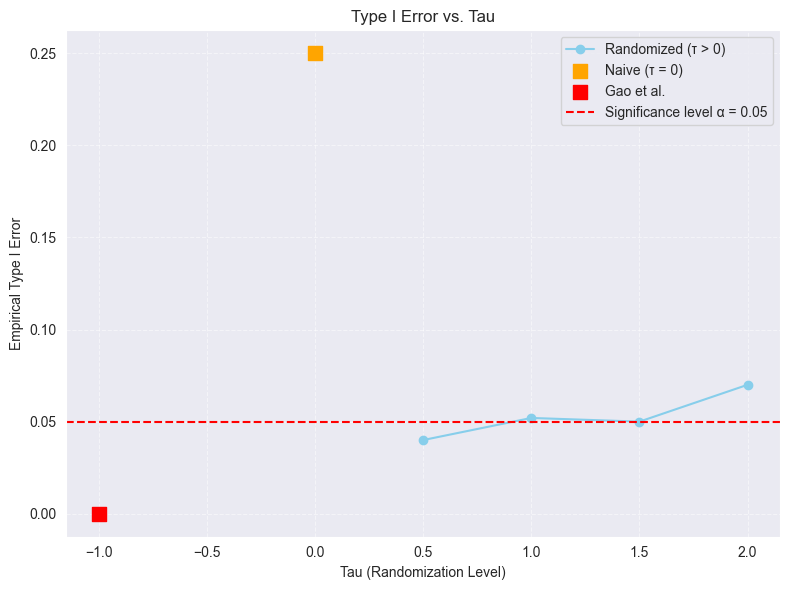

{0: np.float64(0.25),
 0.5: np.float64(0.04),
 1: np.float64(0.052),
 1.5: np.float64(0.05),
 2: np.float64(0.07),
 'baseline': np.float64(0.0)}

In [100]:
tau_list = [0,0.5,1,1.5,2]
check_type1_multi_tau(20,15,1,tau_list,K=3,layer=-1)

# Power


In [125]:

def generate_3cluster_data(n=30, p=2, delta=10.0, sigma=1.0, random_state=None, return_labels=True):
    if n % 3 != 0:
        raise ValueError("n must be divisible by 3.")
    rng = np.random.default_rng(random_state)
    n_cluster = n // 3

    # Cluster 0 at -delta
    mu1 = np.zeros(p)
    mu1[0] = -delta/2

    # Cluster 1 at 0
    mu2 = np.zeros(p)
    mu2[-1] = np.sqrt(3) * delta / 2

    # Cluster 2 at +delta
    mu3 = np.zeros(p)
    mu3[0] = delta/2

    X1 = rng.normal(loc=mu1, scale=sigma, size=(n_cluster, p))
    X2 = rng.normal(loc=mu2, scale=sigma, size=(n_cluster, p))
    X3 = rng.normal(loc=mu3, scale=sigma, size=(n_cluster, p))

    X = np.vstack([X1, X2, X3])
    labels = np.array([0] * n_cluster + [1] * n_cluster + [2] * n_cluster)

    if return_labels:
        return X, labels
    else:
        return X

In [126]:
X, lab = generate_3cluster_data()
%R -i X
%R -i lab

In [133]:
%%R
fit_model <- function(X,K,linkage,method ="euclidean"){
     hcl <- hclust(dist(X, method="euclidean")^2, method=linkage) 
     k_cluster_label <- cutree(hcl, k =K+1)
     return(list(hcl,k_cluster_label))
}
baseline_pval_w_label <- function(X,K, linkage, true_label, method = "euclidean"){
    model <- fit_model(X,K,linkage,method)
    hcl <- model[[1]]
    label <- model[[2]]
    last_pair = get_last_pair(hcl,K)
    c1_points =  which(label == last_pair[1])
    c2_points = which(label == last_pair[2])
    c1_true_cluster = true_label[c1_points]
    c2_true_cluster = true_label[c2_points]
    
    true1 = length(table(c1_true_cluster))
    true2 = length(table(c2_true_cluster))
    
    pval <- NA
    if (true1==1 & true2==1){
       pval <- test_hier_clusters_exact(X, link=linkage, K=K+1, k1=last_pair[1], k2=last_pair[2], hcl=hcl)$pval
    }
    
    return(pval)
}
#baseline_pval_w_label(X,2, "single", lab, method = "euclidean")

In [134]:
def get_baseline_pval_power(X, K, linkage="single", true_label=None):
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['X'] = ro.conversion.py2rpy(X)
        ro.globalenv['true_label'] = ro.conversion.py2rpy(true_label)
    
    ro.globalenv['K_py'] = K
    ro.globalenv['link_py'] = linkage

    # Make sure the R function baseline_pval_w_label is already defined
    pval = ro.r("baseline_pval_w_label(X, K_py, link_py, true_label)")[0]
    return pval

In [148]:
def power_baseline(n, p, sigma, delta, alpha=0.05, num_trials=5000,max_trials = 50000):
    p_values = []
    recovery = []
    iter = 0
    while len(p_values) < num_trials and iter<max_trials:
        X, true_labels = generate_3cluster_data(n,p, delta,sigma)
        pval = get_baseline_pval_power(X,2,"single",true_labels)
        if not np.isnan(pval):
            p_values.append(pval)
            recovery.append(1)
            
        else:
            recovery.append(0)
        
        iter = iter + 1
    p_values = np.array(p_values)
    power = np.mean(p_values<alpha)
    recovery_rate = np.mean(recovery)
    success = len(p_values) == num_trials
    return power, recovery_rate, success

In [149]:
power_baseline(6,2,1,5)

(np.float64(0.2632), np.float64(1.0), True)

In [150]:
def single_tau_power(tau, n, p, sigma, delta, alpha, num_trials, max_attempts=50000):
    p_values = []
    recovery = 0
    trial_count = 0

    while len(p_values) < num_trials:
        trial_count += 1
        X, true_labels = generate_3cluster_data(n=n, p=p, delta=delta, sigma=sigma)
        model = AgglomerativeClustering(X, tau=tau, n_clusters=2, linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[-1]
        c1, c2 = key[0], key[1]
        c1_points = c1.points
        c2_points = c2.points

        c1_true_clusters = set(true_labels[c1_points])
        c2_true_clusters = set(true_labels[c2_points])

        if len(c1_true_clusters) == 1 and len(c2_true_clusters) == 1:
            recovery += 1
            node = c1.parent
            p_val, _, _ = model.merge_inference(node, grid_width=20, ncoarse=20, ngrid=1000, sd=sigma)
            p_values.append(p_val)

        if trial_count > max_attempts:
            print(f"Warning: Too few matching merges at tau={tau}")
            break

    power = np.mean(np.array(p_values) < alpha)
    recovery_prob = recovery / trial_count
    success = len(p_values) == num_trials
    return tau, power, recovery_prob, success

def check_power_multi_tau_parallel(n, p, sigma, tau_list, delta=10.0, alpha=0.05,
                                    num_trials=300, n_jobs=-1):
    
    baseline_power, baseline_recovery, success = power_baseline(n=n, p=p, sigma=sigma, delta=delta,
                                                    alpha=alpha, num_trials=num_trials)
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(single_tau_power)(tau, n, p, sigma, delta, alpha, num_trials)
        for tau in tau_list
    )

    # Unpack results
    power_results_sel = {tau: power for tau, power, _, _ in results}
    recovery_results = {tau: rec for tau, _, rec, _ in results}
    full = [success for _, _, _, success in results]
    full.append(success)

    # Plotting (same as before)
    tau_vals = np.array(tau_list)
    power_vals = [power_results_sel[tau] for tau in tau_vals]
    recovery_vals = [recovery_results[tau] for tau in tau_vals]

    fig, ax1 = plt.subplots(figsize=(8, 6))

    color_power = 'tab:blue'
    ax1.set_xlabel("Tau (Randomization Level)")
    ax1.set_ylabel("Conditional Power", color=color_power)
    ax1.tick_params(axis='y', labelcolor=color_power)
    ax1.set_ylim(0, 1)
    
    ax1.scatter(-1, baseline_power, color='red', marker='s', s=100, label="Gao et al.", zorder=5)

    if 0 in tau_vals:
        naive_idx = np.where(tau_vals == 0)[0][0]
        ax1.scatter(tau_vals[naive_idx], power_vals[naive_idx], color='orange', marker='s', s=100, label="Naive Power (τ=0)", zorder=5)

        tau_random = tau_vals[tau_vals != 0]
        power_random = [power_results_sel[t] for t in tau_random]
        ax1.plot(tau_random, power_random, marker='o', color=color_power, label="Randomized Power (τ>0)")
    else:
        ax1.plot(tau_vals, power_vals, marker='o', color=color_power, label="Conditional Power")

    ax2 = ax1.twinx()
    color_recovery = 'tab:red'
    ax2.set_ylabel("Recovery Probability", color=color_recovery)
    ax2.tick_params(axis='y', labelcolor=color_recovery)
    ax2.set_ylim(0, 1)
    
    ax1.scatter(-1, baseline_recovery, color='red', marker='s', s=100, label="Gao et al.", zorder=5)
    if 0 in tau_vals:
        ax2.scatter(tau_vals[naive_idx], recovery_vals[naive_idx], color='darkorange', marker='D', s=100, label="Naive Recovery (τ=0)", zorder=5)
        recovery_random = [recovery_results[t] for t in tau_random]
        ax2.plot(tau_random, recovery_random, marker='s', linestyle='--', color=color_recovery, label="Randomized Recovery (τ>0)")
    else:
        ax2.plot(tau_vals, recovery_vals, marker='s', linestyle='--', color=color_recovery, label="Recovery Probability")

    plt.title("Conditional Power and Recovery Probability vs. Tau")
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    plt.legend(h1 + h2, l1 + l2, loc="upper right")
    plt.show()

    return power_results_sel, recovery_results, full

level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4


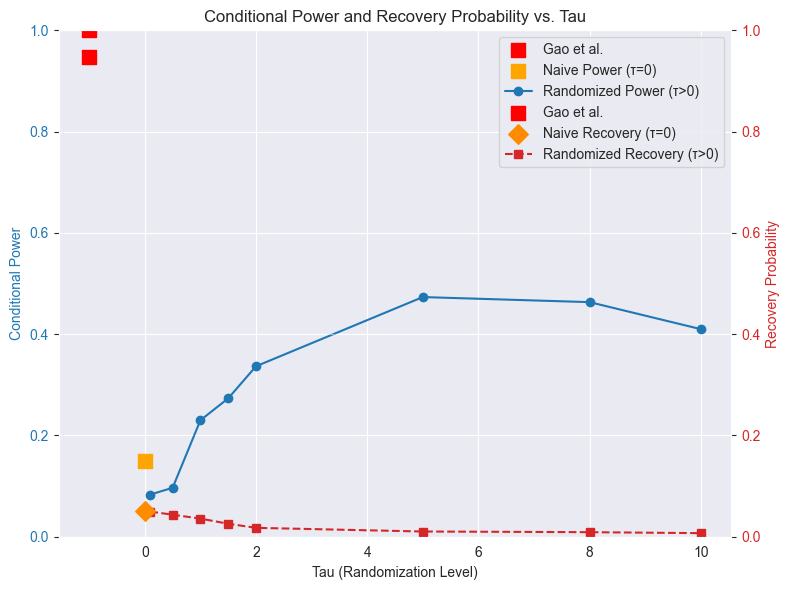

({0: np.float64(0.15),
  0.1: np.float64(0.08333333333333333),
  0.5: np.float64(0.09666666666666666),
  1: np.float64(0.23),
  1.5: np.float64(0.2733333333333333),
  2: np.float64(0.33666666666666667),
  5: np.float64(0.47333333333333333),
  8: np.float64(0.4633333333333333),
  10: np.float64(0.41)},
 {0: 0.05152868430092752,
  0.1: 0.04963600264725347,
  0.5: 0.04344677769732078,
  1: 0.0357824427480916,
  1.5: 0.025638834287667722,
  2: 0.017535655833528174,
  5: 0.010310341272296113,
  8: 0.008980153859969468,
  10: 0.007063477114334149},
 [True, True, True, True, True, True, True, True, True, True])

In [154]:
tau_list = [0,0.1,0.5,1,1.5,2,5,8,10]
check_power_multi_tau_parallel(n=30,p=2,sigma=1,tau_list=tau_list, delta=3.0,alpha=0.05,num_trials=300,n_jobs=-1)